### Replay composition by day
Analysis 1: (past no reward,previous reward,previous,current,future)

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import os
import pickle
import spyglass as nd
import pandas as pd
import statsmodels.api as sm
# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import logging
import multiprocessing

FORMAT = '%(asctime)s %(message)s'

logging.basicConfig(level='INFO', format=FORMAT, datefmt='%d-%b-%y %H:%M:%S')

from spyglass.common import (Session, IntervalList,IntervalPositionInfo,
                             LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
#from spyglass.common.common_interval import _intersection

from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, IntervalPositionInfoSelection


# Here are the analysis tables specific to Shijie Gu
from spyglass.shijiegu.Analysis_SGU import (TrialChoice,
                                   TrialChoiceReplay,
                                   RippleTimes,RippleTimesWithDecode,
                                   DecodeResultsLinear,get_linearization_map,
                                   find_ripple_times,classify_ripples,classify_ripple_content)
from spyglass.shijiegu.PastFuture_Replay import (replay_in_categories,find_distinct_subset,proportion,
                                                 unravel_replay,count_replay_by_category,category_day)
from spyglass.shijiegu.decodeHelpers import runSessionNames

[2026-04-01 09:03:18,798][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
01-Apr-26 09:03:18 DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
dates_to_plot_animals = {}
encoding_sets_animals = {}
classifier_param_names = {}
decode_threshold_methods = {}
success_animals = {}

animal = 'eliot'
dates_to_plot_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

encoding_sets_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_0SD'

animal = 'lewis'
dates_to_plot_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
encoding_sets_animals[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_M05SD'


animal = 'molly'
dates_to_plot_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
encoding_sets_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_M05SD'

animal = 'julio'
dates_to_plot_animals[animal] = ['20230801','20230802','20230803','20230804','20230805',
                 '20230806','20230807','20230808','20230809','20230810','20230811'
                ]
encoding_sets_animals[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_0SD'

animal = 'klein'

dates_to_plot_animals[animal] = ['20231101','20231102','20231103','20231104','20231105','20231106','20231107','20231108',
                 '20231109','20231111','20231112','20231113','20231114'
                ]
encoding_sets_animals[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshold_methods[animal] = 'MUA_0SD'


In [5]:
# BY DAY
categories_H=['home','past','past_reward','future_H']
plot_categories_H=['home','past','past_reward','future',]
categories_O=['home','past','past_reward','current','future_O']
plot_categories_O=['home','past','past_reward','current','future']

In [6]:
from spyglass.shijiegu.fragmented_content import ripple_times_to_content_animal

[09:03:32][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
01-Apr-26 09:03:32 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [13]:
contents_home, duration_home = ripple_times_to_content_animal(animal, ["20220418"],
               categories = categories_H, animal_location = "home",
               classifier_param_name = classifier_param_names[animal],
               encoding_set = encoding_sets_animals[animal],
               decode_threshold_method = decode_threshold_methods[animal],
               fragmented = False, mode = 'acausal',use_1d_decode = False)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220418_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220418_ 2         02_Seq2Session pos 1 valid ti
molly20220418_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220418_ 4         04_Seq2Session pos 3 valid ti
molly20220418_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220418_ 6         06_Seq2Session pos 5 valid ti
molly20220418_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220418_ 8         08_Seq2Session pos 7 valid ti
molly20220418_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220418_ 10        10_Seq2Session pos 9 valid ti
molly20220418_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)



In [29]:
contents_home_animal_f = {}
duration_home_animal_f = {}
contents_home_animal_c = {}
duration_home_animal_c = {}

success_animal = {}
for animal in ["molly", "klein", "julio", "lewis","eliot"]:
    contents_home_animal_f[animal], duration_home_animal_f[animal] = ripple_times_to_content_animal(
                    animal, dates_to_plot_animals[animal],
                   categories = categories_H, animal_location = "home",
                   classifier_param_name = classifier_param_names[animal],
                   encoding_set = encoding_sets_animals[animal],
                   decode_threshold_method = decode_threshold_methods[animal],
                   fragmented = True, mode = 'acausal',use_1d_decode = True)

    contents_home_animal_c[animal], duration_home_animal_c[animal] = ripple_times_to_content_animal(
                    animal, dates_to_plot_animals[animal],
                   categories = categories_H, animal_location = "home",
                   classifier_param_name = classifier_param_names[animal],
                   encoding_set = encoding_sets_animals[animal],
                   decode_threshold_method = decode_threshold_methods[animal],
                   fragmented = False, mode = 'acausal',use_1d_decode = True)
    
    success_animal[animal] = True
    
    output_folder = f'/stelmo/shijie/fragmented_analysis/home_replay_{animal}'
    data = {"contents_home_f": contents_home_animal_f[animal],
            "duration_home_f": duration_home_animal_f[animal],
            "contents_home_c":contents_home_animal_c[animal],
            "duration_home_c": duration_home_animal_c[animal]}
    file_path = output_folder + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    
# contents_outer, duration_outer = ripple_times_to_content_animal(animal, dates_to_plot_animals[animal],
#                categories = categories_O, animal_location = "well",
#                classifier_param_name = classifier_param_names[animal],
#                encoding_set = encoding_sets_animals[animal],
#                decode_threshold_method = decode_threshold_methods[animal],
#                fragmented = True, mode = 'acausal',use_1d_decode = False)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220416_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220416_ 2         02_Seq2Session pos 1 valid ti
molly20220416_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220416_ 4         04_Seq2Session pos 3 valid ti
molly20220416_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220416_ 6         06_Seq2Session pos 5 valid ti
molly20220416_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220416_ 8         08_Seq2Session pos 7 valid ti
molly20220416_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220416_ 10        10_Seq2Session pos 9 valid ti
molly20220416_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220417_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220417_ 2         02_Seq2Session pos 1 valid ti
molly20220417_ 3         03_Seq2Sleep2  pos 2 valid

KeyError: 0

In [27]:
%debug

> /home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/datajoint/fetch.py(332)__call__()
    330             )
    331             if len(result) != 1:
--> 332                 raise DataJointError(
    333                     "fetch1 should only return one tuple. %d tuples found" % len(result)
    334                 )



ipdb>  u


> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/load.py(208)load_decode()
    206 
    207         # decode_1d, decode_2d
--> 208         decode_path1d = entry.fetch1('posterior_1d')
    209         results1d = xr.open_zarr(decode_path1d, consolidated=False)
    210 



ipdb>  exit


In [31]:
success_animal

{'molly': True, 'klein': True, 'julio': True, 'lewis': True}

In [32]:
### plot

[Text(0, 0, 'home'),
 Text(1, 0, 'past'),
 Text(2, 0, 'past reward'),
 Text(3, 0, 'future')]

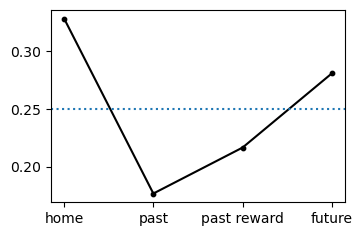

In [15]:
fig, axes = plt.subplots(1,1, figsize=(3.8, 2.5))
for d in contents_home:
    axes.plot([0,1,2,3], contents_home[d], color = "k")
    axes.scatter([0,1,2,3], contents_home[d], color = "k", s= 10)

axes.axhline(0.25, linestyle = ":")
axes.set_xticks([0,1,2,3])
axes.set_xticklabels(['home','past','past reward','future'])

In [35]:
contents_home

({'20220416': array([0.14405622, 0.24195544, 0.24846229, 0.25546425]),
  '20220417': array([0.14785509, 0.2374932 , 0.23896909, 0.25232854]),
  '20220418': array([0.14262378, 0.23015853, 0.2458684 , 0.25456112]),
  '20220419': array([0.15369721, 0.2382025 , 0.24561755, 0.25862124]),
  '20220420': array([0.13065085, 0.24456536, 0.24441269, 0.25588821])},)

In [38]:
contents_home[d][1:]

array([0.24195544, 0.24846229, 0.25546425])

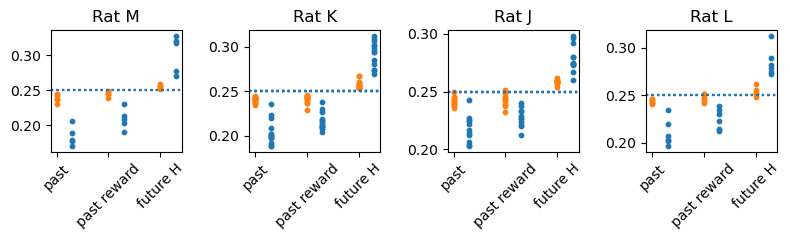

In [52]:
### for all animals
animals = ["molly", "klein", "julio", "lewis",]

fig, axes = plt.subplots(1,len(animals), figsize=(8, 2.5))

animal_ind = 0
for animal in animals:

    output_folder = f'/stelmo/shijie/fragmented_analysis/home_replay_{animal}'
    
    file_path = output_folder + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    contents_home_f = data["contents_home_f"]
    contents_home_c = data["contents_home_c"]

    contents_home = contents_home_f
    contents_home_c = contents_home_c
    for d in contents_home:
        axes[animal_ind].scatter([0,1,2], contents_home[d][1:], color = "C1", s= 10, label = "frag")
        axes[animal_ind].scatter(np.array([0,1,2]) + 0.3, contents_home_c[d][1:], color = "C0", s= 10, label = "cont")
        # for cat in range(3):
        #     axes[animal_ind].plot(np.array([0,0.3]) + cat, [contents_home[d][cat + 1], contents_home_c[d][cat + 1]], color = "grey")
    
        axes[animal_ind].axhline(0.25, linestyle = ":")
        axes[animal_ind].set_xticks([0,1,2])
        axes[animal_ind].set_xticklabels(['past','past reward','future H'], rotation = 45)
        axes[animal_ind].set_title(f"Rat {animal[0].upper()}")
        #axes[animal_ind].legend(bbox_to_anchor=(0.5, -0.3), loc='upper center')
    
    animal_ind += 1
#plt.title("orange: fragmented; blue: continuous")
plt.tight_layout()

In [63]:
duration_outer

{'20240105': 2.32999849319458,
 '20240106': 1.4939985275268555,
 '20240107': 2.9659981727600098,
 '20240108': 3.0199992656707764,
 '20240109': 1.0139999389648438,
 '20240110': 0.8119997978210449}

In [64]:
duration_home

{'20240105': 17.549992084503174,
 '20240106': 15.579993963241577,
 '20240107': 17.56798815727234,
 '20240108': 15.87398910522461,
 '20240109': 27.261990547180176,
 '20240110': 15.203991413116455}

In [57]:
contents_home

{'20240105': array([0.13704761, 0.2466983 , 0.24889956, 0.25610216]),
 '20240106': array([0.12616349, 0.24535365, 0.25276753, 0.24679563]),
 '20240107': array([0.135086  , 0.24571555, 0.24900901, 0.24732801]),
 '20240108': array([0.13658298, 0.25090461, 0.24960931, 0.25458078]),
 '20240109': array([0.11854882, 0.24238872, 0.23937303, 0.25130693]),
 '20240110': array([0.12261252, 0.24539569, 0.24058385, 0.2676181 ])}

In [58]:
contents_outer

{'20240105': array([0.14489014, 0.23419222, 0.23726062, 0.26830838, 0.24601911]),
 '20240106': array([0.08386567, 0.24132994, 0.25652247, 0.26570691, 0.22473143]),
 '20240107': array([0.13488176, 0.22938534, 0.24480321, 0.26533341, 0.231265  ]),
 '20240108': array([0.12999217, 0.20808287, 0.20344089, 0.30404938, 0.24658446]),
 '20240109': array([0.10896211, 0.20312721, 0.22688282, 0.27855866, 0.26894464]),
 '20240110': array([0.09009695, 0.20429847, 0.26529072, 0.26029527, 0.22204216])}

In [14]:
# choice reward 
key = {"nwb_file_name": "molly20220418_.nwb","epoch":8}
df = pd.DataFrame((TrialChoice() & key).fetch1("choice_reward"))

# ripple data

In [23]:
key = {"nwb_file_name": "molly20220418_.nwb",
       "interval_list_name":"08_Seq2Session4",
      "decode_threshold_method":"MUA_M05SD"}
ripple_times = pd.read_pickle((RippleTimesWithDecode() & key).fetch1("ripple_times"))

In [35]:
pd.DataFrame((RippleTimes() & key).fetch1("ripple_times"))

,start_time,end_time,duration,mean_zscore,median_zscore,max_zscore,min_zscore,max_speed,min_speed,median_speed,mean_speed
1,1.650320e+09,1.650320e+09,0.450001,2.680446,1.640251,15.524033,0.017042,3.980120,0.828265,2.524762,2.260941
2,1.650320e+09,1.650320e+09,0.112000,1.077435,0.269616,4.341145,-0.238244,1.652563,1.258292,1.518767,1.503592
3,1.650320e+09,1.650320e+09,0.174001,1.076139,0.705042,3.628487,-0.164233,3.995385,1.918595,2.164717,2.385170
4,1.650320e+09,1.650320e+09,0.153000,1.145110,0.886384,3.978843,0.012533,0.985830,0.956695,0.973583,0.972493
5,1.650320e+09,1.650320e+09,0.100000,1.217746,0.610086,4.759939,-0.935282,0.567308,0.260570,0.396313,0.397605
...,...,...,...,...,...,...,...,...,...,...,...
252,1.650322e+09,1.650322e+09,0.127000,0.971712,0.742497,3.768176,-0.345064,3.095585,1.213173,2.584477,2.461132
253,1.650322e+09,1.650322e+09,0.127000,2.274219,0.926477,8.868504,-0.449915,0.371029,0.118470,0.181241,0.214833
254,1.650322e+09,1.650322e+09,0.105000,1.218609,0.647792,4.908957,-0.930442,0.388874,0.303012,0.378099,0.364749
255,1.650322e+09,1.650322e+09,0.102000,3.302666,1.560106,13.165832,-0.629733,0.425135,0.171711,0.339087,0.325612


In [29]:
RippleTimesWithDecode()

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,decode_threshold_method a name for this thresholding method,ripple_times ripple times within that interval
eliot20221017_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_05SD,=BLOB=
eliot20221017_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_0SD,=BLOB=
eliot20221017_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_05SD,=BLOB=
eliot20221017_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_0SD,=BLOB=
eliot20221017_.nwb,06_Seq2Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_05SD,=BLOB=
eliot20221017_.nwb,06_Seq2Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_0SD,=BLOB=
eliot20221017_.nwb,08_Seq2Session4,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_05SD,=BLOB=
eliot20221017_.nwb,08_Seq2Session4,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_0SD,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_05SD,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,MUA_0SD,=BLOB=


In [37]:
DecodeResultsLinear()

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,posterior posterior within that interval (1D)
eliot20221017_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221017_.nwb,04_Seq2Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221017_.nwb,06_Seq2Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221017_.nwb,08_Seq2Session4,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,all_maze,=BLOB=
eliot20221018_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze_3states,all_maze,=BLOB=
eliot20221018_.nwb,04_Seq2Session2,causal_decoding_gpu_4armMaze,2Dheadspeed_above_4_andlowmua,=BLOB=


In [28]:
ripple_times.loc[:20]

,event_number,start_time,animal_location,trial_number,cont_intvl,frag_intvl,cont_intvl_replay,end_time,duration,mean_zscore,median_zscore,max_zscore,min_zscore,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
0,1,1.650320e+09,home,2,"[[1650320193.77939, 1650320194.22739]]",[],[[0]],1.650320e+09,0.450001,172.972944,136.801250,619.594826,80.355937,3.980120,3.512018,3.980120,0.828265,2.524762,2.260941
1,2,1.650320e+09,well4,2,"[[1650320206.7673843, 1650320206.8573844]]",[],[[4]],1.650320e+09,0.092000,125.949682,96.495448,230.721947,79.786602,1.433695,1.375526,1.652563,1.375526,1.541421,1.539179
2,3,1.650320e+09,center1,2,"[[1650320226.5093758, 1650320226.6773756]]",[],[[]],1.650320e+09,0.170001,118.152592,105.385821,205.940035,80.850373,3.995385,2.065238,3.995385,1.918595,2.165425,2.393145
3,4,1.650320e+09,center1,2,"[[1650320226.9413755, 1650320227.0913756]]",[],[[]],1.650320e+09,0.153000,119.583266,110.586344,218.123294,80.199142,0.985830,0.956695,0.985830,0.956695,0.973583,0.972493
4,5,1.650320e+09,center1,2,"[[1650320227.1093757, 1650320227.2553754]]",[],[[]],1.650320e+09,0.148000,136.939847,136.786094,199.767142,82.858487,0.956494,3.964098,3.964098,0.956167,1.117772,1.581691
5,6,1.650320e+09,home,5,"[[1650320245.2213676, 1650320245.2553675]]",[],[[0]],1.650320e+09,0.035000,141.420090,158.386971,172.529896,80.821901,2.269478,2.614973,2.614973,2.269478,2.506423,2.480523
6,7,1.650320e+09,home,5,"[[1650320248.783366, 1650320248.8213658]]",[],[[1]],1.650320e+09,0.067000,145.781126,120.998832,245.285057,79.962503,0.261527,0.532153,0.532153,0.260570,0.408904,0.403380
7,8,1.650320e+09,well2,5,"[[1650320261.2433603, 1650320261.3073604]]",[],[[2]],1.650320e+09,0.066000,139.424516,142.933374,208.908691,80.223781,1.234444,2.533852,2.533852,1.234444,1.862493,1.866423
8,9,1.650320e+09,well2,5,"[[1650320261.4133604, 1650320261.5533602]]",[],[[2]],1.650320e+09,0.142000,120.623282,111.260184,248.201655,80.676576,3.746476,2.408498,3.775967,2.408498,3.303399,3.233788
9,10,1.650320e+09,well2,5,"[[1650320261.6113603, 1650320261.69936]]",[],[[2]],1.650320e+09,0.089000,151.591524,129.712174,231.641151,81.687007,2.060090,3.971532,3.971532,2.060090,2.523917,2.663820


In [27]:
df.loc[:20]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,current,future_H,future_O,past,past_reward
1,1.650320e+09,1.0,1.650320e+09,3.0,2.0,3.0,3.0,4.0,NaN,NaN
2,1.650320e+09,1.0,1.650320e+09,4.0,2.0,4.0,4.0,1.0,3.0,3.0
3,NaN,NaN,1.650320e+09,1.0,0.0,1.0,1.0,3.0,4.0,4.0
4,1.650320e+09,1.0,1.650320e+09,3.0,1.0,3.0,3.0,2.0,1.0,4.0
5,1.650320e+09,1.0,1.650320e+09,2.0,2.0,2.0,2.0,4.0,3.0,4.0
6,1.650320e+09,1.0,1.650320e+09,4.0,1.0,4.0,4.0,1.0,2.0,2.0
7,1.650320e+09,1.0,1.650320e+09,1.0,2.0,1.0,1.0,3.0,4.0,2.0
8,1.650320e+09,1.0,1.650320e+09,3.0,2.0,3.0,3.0,4.0,1.0,1.0
9,1.650320e+09,1.0,1.650320e+09,4.0,2.0,4.0,4.0,1.0,3.0,3.0
10,1.650320e+09,1.0,1.650320e+09,1.0,1.0,1.0,1.0,3.0,4.0,4.0


In [18]:
def bootstrap_random_day(b,nwb_copy_file_name,epochs_to_run,categories_H,plot_categories_H):
    np.random.seed(b)
    categories_H_day=category_day(nwb_copy_file_name,epochs_to_run,
                                  categories_H,plot_categories_H,
                                  simulate_random_flag=True)

    return proportion(categories_H_day)

#### 1. subset trials analysis

In [19]:
for ni in range(len(nwb_file_names)):
    nwb_file_name=nwb_file_names[ni]
    nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
    session_interval, position_interval = runSessionNames(nwb_copy_file_name)
    
    if len(all_epochs_flag[ni])==0:
        epochs_to_run = session_interval
    else:
        epochs_to_run = session_interval[ni]
    
    count_H_day=category_day(nwb_copy_file_name,
                              epochs_to_run,categories_H,plot_categories_H)
    #count_O_day=category_day(nwb_copy_file_name,
    #                          epochs_to_run,categories_O,plot_categories_O)
    
    prop_H_day,total_H_day=proportion(count_H_day)
    #prop_O_day,total_O_day=proportion(count_O_day)
    
    B=100
    #with multiprocessing.Pool(10) as p:
    #    results=p.map(bootstrap_random_day,[b for b in range(B)])
    results = []
    for b in range(B):
        print(b)
        results.append( bootstrap_random_day(b,nwb_copy_file_name,epochs_to_run,categories_H,plot_categories_H) )
    
    prop_H_boot=np.zeros((B,len(count_H_day)))
    #prop_O_boot=np.zeros((B,len(count_O_day)))

    for b in range(B):
        categories_names=list(results[b][0].keys())
        for ki in range(len(categories_names)):
            prop_H_boot[b,ki]=results[b][0][categories_names[ki]]

        #categories_names=list(results[b][1][0].keys())
        #for ki in range(len(categories_names)):
        #    prop_O_boot[b,ki]=results[b][1][0][categories_names[ki]]
    
    
    H_boot_mean=np.mean(prop_H_boot,axis=0)
    H_boot_CI=np.quantile(prop_H_boot,[p_value,1-p_value],axis=0)
    
    animal=nwb_file_name[:5]
    date=nwb_copy_file_name[5:-5]
    decoding_path=(DecodeResultsLinear &
                   {'nwb_file_name': nwb_copy_file_name}).fetch('posterior')[0]
    resultfolder=os.path.join(os.path.split(decoding_path)[0],'analysis')
    isExist = os.path.exists(resultfolder)
    if not isExist:
        os.makedirs(resultfolder)

    data={'categories_H_day_prop':prop_H_day,
          'categories_H_num':total_H_day,
          'H_boot_mean':H_boot_mean,
          'H_boot_CI':H_boot_CI,
         }

    with open(os.path.join(resultfolder,'replay_category_'+animal+'_'+date+'.p'), 'wb') as handle:
        pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)

number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
0
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
1
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
2
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
3
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
4
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
5
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
6
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
7
number of valid trials: 28
number of valid trials: 43
number of valid trials: 22
number of valid trials: 27
8
number of 

In [15]:
nwb_copy_file_name

'lewis20240108.nwblewis20240109_.nwb'

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.8/site-packages/datajoint/connection.py:341: UserWarning: MySQL server has gone away. Reconnecting to the server.
  warnings.warn("MySQL server has gone away. Reconnecting to the server.")


In [269]:
pickle.load(open(os.path.join(resultfolder,'replay_category_'+animal+'_'+date+'.p'),"rb"))

{'categories_H_day_prop': {'home': 0.928921568627451,
  'past': 0.00980392156862745,
  'past_reward': 0.024509803921568627,
  'future': 0.03676470588235294},
 'categories_H_num': 408,
 'categories_O_day_prop': {'home': 0.055865921787709494,
  'past': 0.00558659217877095,
  'past_reward': 0.0148975791433892,
  'current': 0.9087523277467412,
  'future': 0.0148975791433892},
 'categories_O_num': 537,
 'O_boot_mean': array([0.04022813, 0.2159799 , 0.19078607, 0.34898956, 0.20401634]),
 'O_boot_std': array([0.00737292, 0.02316715, 0.01598242, 0.02195183, 0.03288566]),
 'H_boot_mean': array([0.75362365, 0.07331474, 0.09694438, 0.07611724]),
 'H_boot_std': array([0.02135901, 0.0164067 , 0.01245653, 0.01091013])}

#### 2. all trials with GLM

In [ ]:
def GLM_replay(nwb_file_name,epochs,replay_location,categories,plot_categories):
    '''
    replay_location: 'replay_H' or 'replay_O'
    '''

    nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

    betas={}
    
    y_day=[]
    x_day=[]
    
    for epoch_num in epochs:

        # get all replay
        key={'nwb_file_name':nwb_copy_file_name,'epoch':epoch_num}
        replay_df_subset=pd.DataFrame((TrialChoiceReplay & key).fetch1('choice_reward_replay'))

        # get behavior
        behavior_df=get_df_tally(nwb_file_name,epoch_num)

        # create regresser matrix
        if categories[0]=='home':
            y=np.zeros((5*len(replay_df_subset.index),1))
            x=np.zeros((5*len(replay_df_subset.index),len(categories)))
        else:
            y=np.zeros((4*len(replay_df_subset.index),1))
            x=np.zeros((4*len(replay_df_subset.index),len(categories)))

        for i in range(len(replay_df_subset.index)):
            t=replay_df_subset.index[i]

            replay=np.array(unravel_replay([list(replay_df_subset.loc[t,replay_location])])[0])
            if categories[0]=='home':
                for a in range(4):
                    arm=a+1
                    y[i*5+a+1,0]=np.sum(replay==arm)
                for c in range(1,len(categories)):
                    correponding_arm=behavior_df.loc[t,categories[c]]
                    if not np.isnan(correponding_arm):
                        x[i*5+int(correponding_arm),c]=1
                # home
                x[i*5,0]=1
                y[i*5,0]=np.sum(replay==0)
            else:
                for a in range(4):
                    arm=a+1
                    y[i*4+a,0]=np.sum(replay==arm)
                for c in range(len(categories)):
                    correponding_arm=behavior_df.loc[t,categories[c]]
                    if not np.isnan(correponding_arm):
                        x[i*4+int(correponding_arm)-1,c]=1
                        
        x_day.append(x)
        y_day.append(y)
    x_day=np.concatenate(x_day,axis=0)
    y_day=np.concatenate(y_day,axis=0)
       
    
    # do GLM
    x_ = sm.add_constant(x)
    glm_poisson = sm.GLM(y,x_,family=sm.families.Poisson())
    res = glm_poisson.fit()
    CI=res.conf_int(alpha=0.05)
    print(res.summary())
    
    for c in range(len(plot_categories)):
        betas[plot_categories[c]]=(np.exp(res.params[c+1]),np.exp(CI[c+1])) #plus one because of the constant term
    
    return betas

In [ ]:
categories=['past','past_reward','current','future']
plot_categories=['past','past_reward','future','future t+1']
replay_location='replay_H'
betas_H=GLM_replay(nwb_file_name,epochs,replay_location,categories,plot_categories)

categories=['past','past_reward','current','future']
plot_categories=['past','past_reward','current','future']
replay_location='replay_O'
betas_O=GLM_replay(nwb_file_name,epochs,replay_location,categories,plot_categories)


epoch name 02_SeqSession1
epoch name 04_Seq2Session1
epoch name 06_Seq2Session2
epoch name 08_Seq2Session3
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  304
Model:                            GLM   Df Residuals:                      299
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -174.87
Date:                Sat, 09 Jul 2022   Deviance:                       216.23
Time:                        13:55:46   Pearson chi2:                     323.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1018
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------

In [ ]:
betas_H

{'past': (0.2518171081386721, array([0.08449668, 0.75046568])),
 'past_reward': (0.8322678663709008, array([0.40975283, 1.69045763])),
 'future': (1.6947690205170083, array([0.92057769, 3.12004306])),
 'future t+1': (1.8403140628336758, array([1.01900775, 3.32358202]))}

In [ ]:
betas_O

{'past': (0.6835910288831625, array([0.17562188, 2.6608114 ])),
 'past_reward': (0.31981827412932257, array([0.12867794, 0.79488161])),
 'current': (52.769523322950114, array([ 23.97368396, 116.15330362])),
 'future': (1.2546815295040081, array([0.44761144, 3.51694705]))}

In [181]:
categories_O_day_hat

{'home': 7, 'past': 44, 'past_reward': 45, 'current': 54, 'future': 44}

In [188]:
categories_H_day_hat

{'home': 259, 'past': 29, 'past_reward': 39, 'future': 25}